In [2]:
%load_ext autoreload
%autoreload 2

import sys
import os
import cv2

# Thêm thư mục cha (thư mục gốc của project) vào đường dẫn hệ thống
sys.path.append(os.path.abspath('..'))

import torch
import torch.nn as nn
import numpy as np
from pathlib import Path

# Import từ thư mục core
from core.utils import seed_everything, get_device, build_dataloaders, train_one_epoch, evaluate, count_parameters, plot_history
from core.models import BNN

# Configs
EPOCHS = 5
BATCH_SIZE = 32
LR = 1e-3
VAL_RATIO = 0.1
SEED = 42
OUT_DIR = Path("runs_mnist_bnn")
OUT_DIR.mkdir(parents=True, exist_ok=True)

seed_everything(SEED)
device = get_device()
print(f"Sử dụng thiết bị: {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Sử dụng thiết bị: cpu


In [3]:
# Chú ý: Ở đây bạn có thể bật/tắt việc nhị phân hóa ảnh đầu vào rất dễ dàng
train_loader, val_loader, test_loader = build_dataloaders(
    BATCH_SIZE, VAL_RATIO, SEED, binarize_input=False 
)

model = BNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(f"Tổng tham số BNN: {count_parameters(model):,}")

Failed to read module file 'd:\Repos\BSNN_EdgeAI_Workspace\core\utils.py' for module 'core.utils': UnicodeDecodeError
Traceback (most recent call last):
  File "d:\Repos\BSNN_EdgeAI_Workspace\.venv\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 219, in update_sources
    self.source_by_modname[new_modname] = f.read()
                                          ^^^^^^^^
  File "C:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x90 in position 866: character maps to <undefined>


Tổng tham số BNN: 54,474


In [4]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = -1.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS:02d} | Train: {train_acc*100:.2f}% | Val: {val_acc*100:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}

if best_state is not None:
    torch.save(best_state, OUT_DIR / "best_model.pt")
    model.load_state_dict(best_state)

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print("-" * 40)
print(f"Test accuracy: {test_acc*100:.2f}%")

Epoch 01/05 | Train: 88.05% | Val: 83.97%
Epoch 02/05 | Train: 90.53% | Val: 91.43%
Epoch 03/05 | Train: 92.77% | Val: 92.12%
Epoch 04/05 | Train: 93.15% | Val: 94.87%
Epoch 05/05 | Train: 93.37% | Val: 91.30%
----------------------------------------
Test accuracy: 92.17%


Failed to read module file 'd:\Repos\BSNN_EdgeAI_Workspace\core\utils.py' for module 'core.utils': UnicodeDecodeError
Traceback (most recent call last):
  File "d:\Repos\BSNN_EdgeAI_Workspace\.venv\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 556, in maybe_reload_module
    new_source_code = f.read()
                      ^^^^^^^^
  File "C:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x90 in position 900: character maps to <undefined>


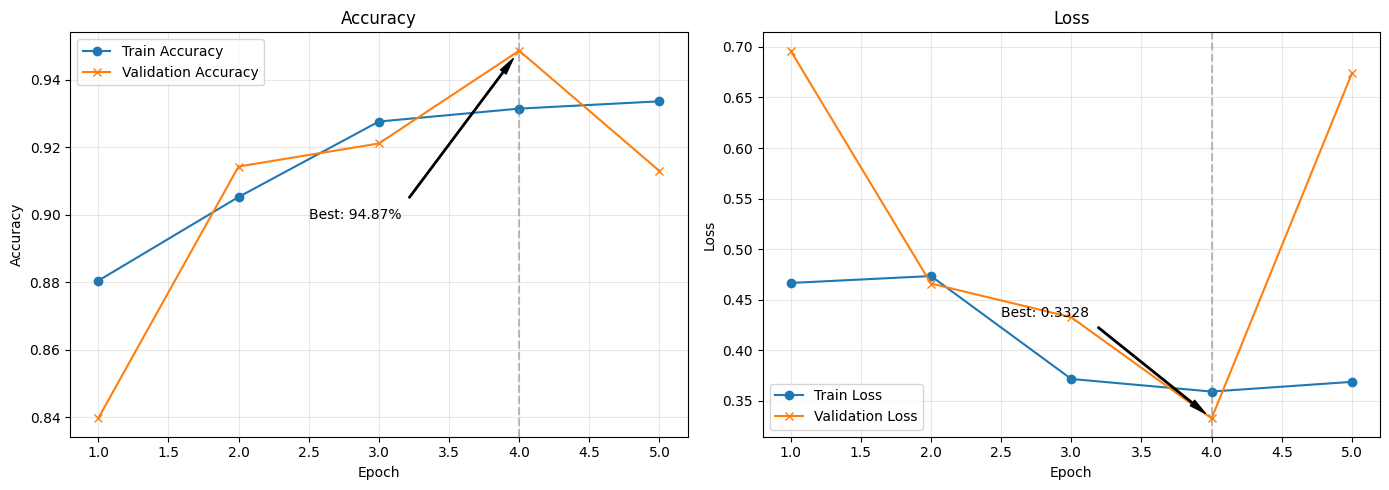

In [5]:
plot_history(history, OUT_DIR)

np.save(OUT_DIR / "train_loss.npy", np.array(history["train_loss"]))
np.save(OUT_DIR / "train_acc.npy", np.array(history["train_acc"]))
np.save(OUT_DIR / "val_loss.npy", np.array(history["val_loss"]))
np.save(OUT_DIR / "val_acc.npy", np.array(history["val_acc"]))


--- Đang dự đoán ảnh từ thư mục: my_validation_img ---


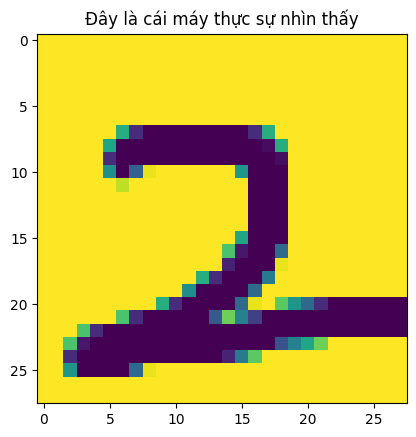

Ảnh: data1.png --> Dự đoán: 8


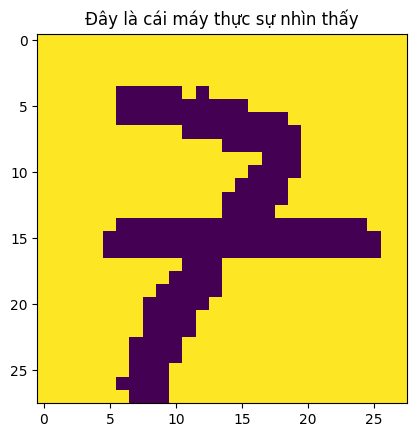

Ảnh: data2.png --> Dự đoán: 8


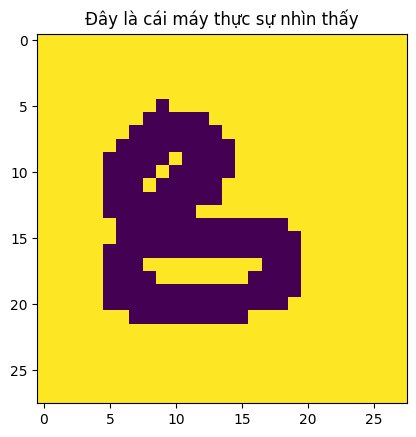

Ảnh: data3.png --> Dự đoán: 3


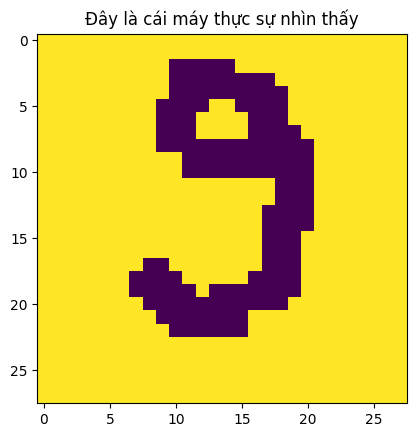

Ảnh: data4.png --> Dự đoán: 8


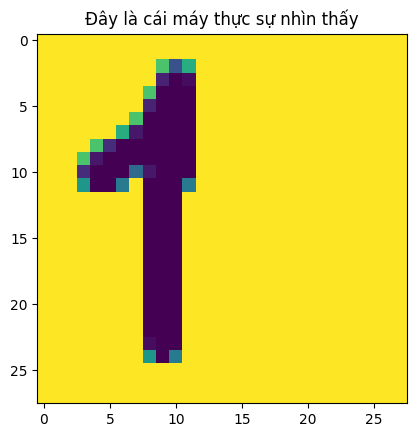

Ảnh: data5.png --> Dự đoán: 3


In [ ]:
import glob
import matplotlib.pyplot as plt
def predict_external_images(model, folder_path, device):
    """
    Hàm load các ảnh từ folder, tiền xử lý và dự đoán nhãn.
    """
    model.eval()
    image_paths = glob.glob(os.path.join(folder_path, "*.*")) # Lấy tất cả file ảnh
    
    if not image_paths:
        print(f"Không tìm thấy ảnh nào trong thư mục: {folder_path}")
        return

    print(f"\n--- Đang dự đoán ảnh từ thư mục: {folder_path} ---")
    
    with torch.no_grad():
        for img_path in image_paths:
            # 1. Đọc ảnh và chuyển về ảnh xám (Grayscale)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            
            # 2. Resize về 28x28 (kích thước của MNIST)
            img_resized = cv2.resize(img, (28, 28))
            
            # 3. Tiền xử lý: Chuyển sang tensor, thêm dimension (Batch, Channel, H, W) và chuẩn hóa
            # MNIST thường là nền đen chữ trắng, nếu ảnh của bạn nền trắng chữ đen thì cần đảo ngược màu:
            # img_resized = 255 - img_resized 
            
            img_tensor = torch.from_numpy(img_resized).float().to(device)
            img_tensor = img_tensor / 255.0  # Chuẩn hóa về [0, 1]
            img_tensor = img_tensor.unsqueeze(0).unsqueeze(0) # Shape: [1, 1, 28, 28]

            # 4. Dự đoán
            output = model(img_tensor)
            pred = output.argmax(dim=1, keepdim=True).item()
            plt.imshow(img.reshape(28, 28), cmap='gray')
            plt.title("Đây là cái máy thực sự nhìn thấy")
            plt.show()
            print(f"Ảnh: {os.path.basename(img_path)} --> Dự đoán: {pred}")

# --- Thực thi dự đoán ---
MY_IMG_DIR = "my_validation_img"
# Đảm bảo folder tồn tại để không bị lỗi
if not os.path.exists(MY_IMG_DIR):
    os.makedirs(MY_IMG_DIR)
    print(f"Vừa tạo thư mục '{MY_IMG_DIR}'. Hãy bỏ ảnh vào đây rồi chạy lại.")
else:
    predict_external_images(model, MY_IMG_DIR, device)